# Quadrangle Weighted Boxes Fusion example: harbor ships

`weighted_boxes_fusion_quadrangle` handles arbitrary four-corner boxes without assuming right angles, matching the ground-truth format.

This notebook:

1. reads the `harbor_ships` image and its labels and draws the labelled boxes,
2. reads simulated predictions of 5 models and draws them,
3. fuses the harbor predictions with `weighted_boxes_fusion_quadrangle` and draws the fused boxes.

Data used (paths are relative to this notebook):

- `data/images/harbor_ships.jpg`
- `data/labels/labels.csv`
- `data/labels/harbor_ships_predictions.csv`

## Install dependencies

In [1]:
%pip install -q numpy pandas matplotlib pillow
# ensemble_boxes from this repository (the folder above this notebook)
%pip install -q -e ..

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


## Imports and settings

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image

from ensemble_boxes import weighted_boxes_fusion_quadrangle
from ensemble_boxes.ensemble_boxes_wbf_quadrangle import bb_intersection_over_union_quadrangle

DATA_DIR = Path('data')
IMAGE_NAME = 'harbor_ships.jpg'
IMAGE_PATH = DATA_DIR / 'images' / IMAGE_NAME
LABELS_PATH = DATA_DIR / 'labels' / 'labels.csv'
PREDICTIONS_PATH = DATA_DIR / 'labels' / '{}_predictions.csv'.format(Path(IMAGE_NAME).stem)

# Columns with the 4 corners of a box, in pixels
CORNER_COLS = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4']
# Number of simulated models in the predictions file
N_MODELS = 5

# WBF settings
IOU_THR = 0.55
SKIP_BOX_THR = 0.0

# NMS setting: boxes of one class with IoU above this value count as the same object
NMS_IOU_THR = 0.5

## Drawing helpers

All pictures in this notebook are made with the same two functions: `new_figure` shows the image and `draw_quadrangles` draws boxes on top of it.

In [3]:
def new_figure(image, title='', crop=None, figsize=(12, 12)):
    """
    Show the image and return the axes to draw on.
    :param crop: optional (x_min, y_min, x_max, y_max) region to zoom into
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    if crop is not None:
        x_min, y_min, x_max, y_max = crop
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_max, y_min)  # image y axis points down
    ax.set_title(title)
    ax.axis('off')
    return ax


def draw_quadrangles(ax, boxes, color='yellow', color_by=None, legend='', linewidth=1.5,
                     width_by_score=False, show_scores=False):
    """
    Draw every row of `boxes` as a 4-corner polygon.
    :param boxes: DataFrame with CORNER_COLS in pixels
    :param color: color of all boxes, used when color_by is not set
    :param color_by: column name, boxes get one color per value of this column
    :param legend: legend text; with color_by it is put before each value
    :param linewidth: line width of all boxes
    :param width_by_score: make the line wider for boxes with a higher 'score'
    :param show_scores: write the 'score' at the center of each box
    """
    cmap = plt.get_cmap('tab10')
    values = sorted(boxes[color_by].unique()) if color_by else []
    in_legend = set()

    for _, row in boxes.iterrows():
        # 4 corners as a (4, 2) array of (x, y) points
        corners = row[CORNER_COLS].to_numpy(dtype=float).reshape(4, 2)
        if color_by:
            value = row[color_by]
            box_color = cmap(values.index(value) % 10)
            text = '{} {}'.format(legend, value).strip()
        else:
            box_color = color
            text = legend
        # Only the first box of each color goes to the legend
        label = text if text and text not in in_legend else None
        in_legend.add(text)

        width = 0.5 + 1.5 * row['score'] if width_by_score else linewidth
        ax.add_patch(Polygon(corners, closed=True, fill=False, edgecolor=box_color, linewidth=width, label=label))

        if show_scores:
            center_x, center_y = corners.mean(axis=0)
            ax.text(center_x, center_y, '{:.2f}'.format(row['score']), color='black', fontsize=11, ha='center', va='center',
                    bbox=dict(facecolor=box_color, edgecolor='none', pad=2))

    if in_legend - {''}:
        # Legend entries sorted by text, so that models are listed in order
        handles, texts = ax.get_legend_handles_labels()
        order = np.argsort(texts)
        ax.legend([handles[i] for i in order], [texts[i] for i in order], loc='lower left')

## Read and show the image

Image shape (height, width, channels): (1024, 1024, 3)


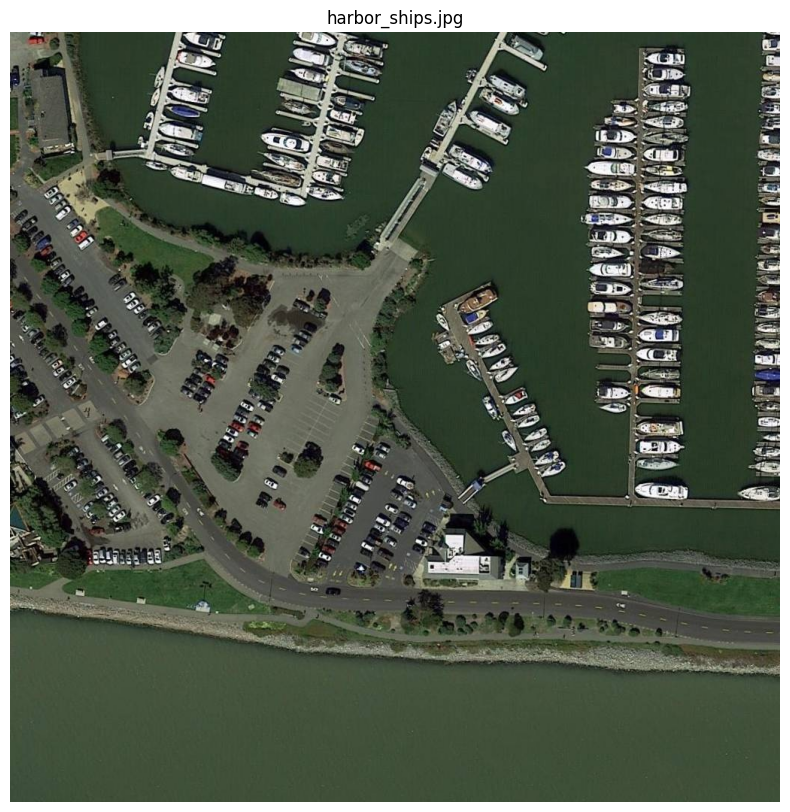

In [4]:
image = np.array(Image.open(IMAGE_PATH).convert('RGB'))
print('Image shape (height, width, channels):', image.shape)

new_figure(image, title=IMAGE_NAME, figsize=(10, 10))
plt.show()

## Read the labels

`labels.csv` has one row per box, for all images. Each box is stored in pixels in two forms:

- `x1, y1, ..., x4, y4`: the 4 corners of the box (quadrangle). The corners do not have to form right angles.
- `cx, cy, w, h, angle_deg`: center, size and rotation angle in degrees of the rectangle fitted to these corners.

In [5]:
labels = pd.read_csv(LABELS_PATH)
print('Boxes per image:')
print(labels['image'].value_counts().to_string())

# Keep only the boxes of our image
boxes = labels[labels['image'] == IMAGE_NAME].reset_index(drop=True)
print()
print('Boxes per class in {}:'.format(IMAGE_NAME))
print(boxes['class_name'].value_counts().to_string())
boxes.head()

Boxes per image:
image
harbor_ships.jpg     110
tennis_courts.jpg     13

Boxes per class in harbor_ships.jpg:
class_name
ship      105
harbor      5


,image,class_id,class_name,x1,y1,x2,y2,x3,y3,x4,y4,cx,cy,w,h,angle_deg
0,harbor_ships.jpg,1,ship,833.0,536.0,834.0,517.0,893.0,517.0,893.0,537.0,863.2,526.5,60.0,20.0,1.0
1,harbor_ships.jpg,1,ship,838.0,462.0,837.0,445.0,892.0,445.0,891.0,464.0,864.5,454.5,55.0,19.0,0.0
2,harbor_ships.jpg,1,ship,832.0,438.0,832.0,419.0,890.0,422.0,889.0,440.0,860.5,430.0,58.1,19.0,3.0
3,harbor_ships.jpg,1,ship,835.0,413.0,836.0,394.0,891.0,396.0,890.0,413.0,863.0,404.5,55.3,19.0,2.1
4,harbor_ships.jpg,1,ship,834.0,391.0,835.0,371.0,894.0,374.0,893.0,392.0,864.0,382.5,59.1,20.0,2.9


## Draw the labels on the image

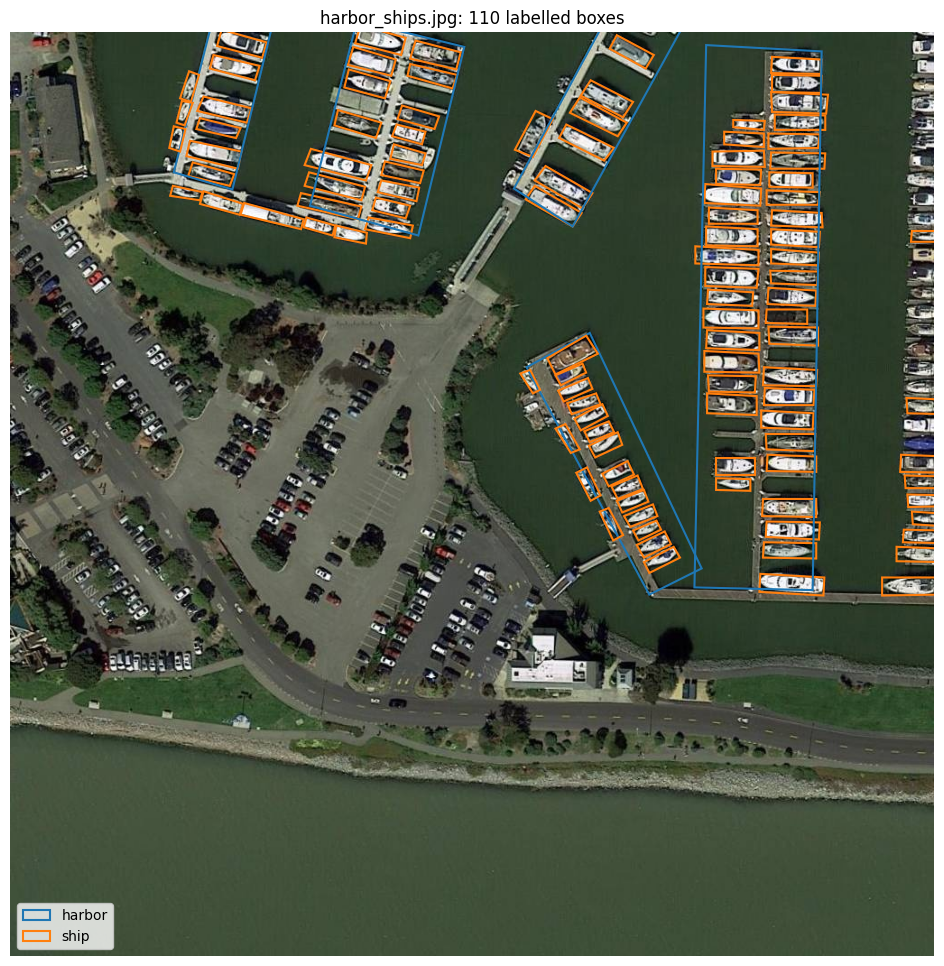

In [6]:
ax = new_figure(image, title='{}: {} labelled boxes'.format(IMAGE_NAME, len(boxes)))
draw_quadrangles(ax, boxes, color_by='class_name')
plt.show()

## Load the predictions

There are no real model outputs for this image, so the predictions are simulated from the labels: each labelled object has 3 to 5 predictions, as if it was detected by 3 to 5 out of 5 different models. Every prediction is the labelled quadrangle with slightly moved corners, and its confidence score is higher when it is closer to the label.

The predictions are read from `labels/harbor_ships_predictions.csv`. The notebook does not write this file. How the file was created is described in the appendix at the end.

`object_id` and `label_error` come from the labels and are kept only to check the result; a real model would not output them.

In [7]:
predictions = pd.read_csv(PREDICTIONS_PATH)
print('Loaded {} predictions from {}'.format(len(predictions), PREDICTIONS_PATH))

print('Objects: {}, predictions: {}'.format(len(boxes), len(predictions)))
print(predictions.groupby('object_id').size().value_counts().sort_index().to_string())
print('Score: min {:.2f}, mean {:.2f}, max {:.2f}'.format(predictions['score'].min(), predictions['score'].mean(), predictions['score'].max()))
predictions.head(8)

Loaded 441 predictions from data/labels/harbor_ships_predictions.csv
Objects: 110, predictions: 441
3    33
4    43
5    34
Score: min 0.30, mean 0.69, max 0.98


,image,object_id,model,class_id,class_name,score,label_error,x1,y1,x2,y2,x3,y3,x4,y4
0,harbor_ships.jpg,0,2,1,ship,0.649,0.0770,833.0,533.4,835.0,514.3,893.4,515.2,895.1,534.4
1,harbor_ships.jpg,0,3,1,ship,0.673,0.0629,834.0,533.8,835.6,515.8,893.5,515.1,894.9,535.6
2,harbor_ships.jpg,0,4,1,ship,0.782,0.0504,832.9,537.2,834.0,520.0,892.1,517.2,891.7,538.4
3,harbor_ships.jpg,1,0,1,ship,0.769,0.0480,838.3,462.9,838.1,445.9,893.8,445.9,892.6,464.8
4,harbor_ships.jpg,1,1,1,ship,0.525,0.0930,838.5,459.7,837.2,442.8,894.3,442.3,892.8,460.5
5,harbor_ships.jpg,1,2,1,ship,0.803,0.0339,838.9,463.5,836.9,445.3,893.0,445.6,890.0,463.7
6,harbor_ships.jpg,1,4,1,ship,0.859,0.0258,839.3,461.8,837.8,445.8,892.3,445.6,891.0,463.8
7,harbor_ships.jpg,2,0,1,ship,0.825,0.0295,832.5,438.5,832.5,418.2,889.2,421.6,888.6,441.3


## Show the predictions

Predictions are colored by model. Line width grows with the confidence score. The second picture zooms into the top right corner so that single ships can be seen, with the labels drawn in white for comparison.

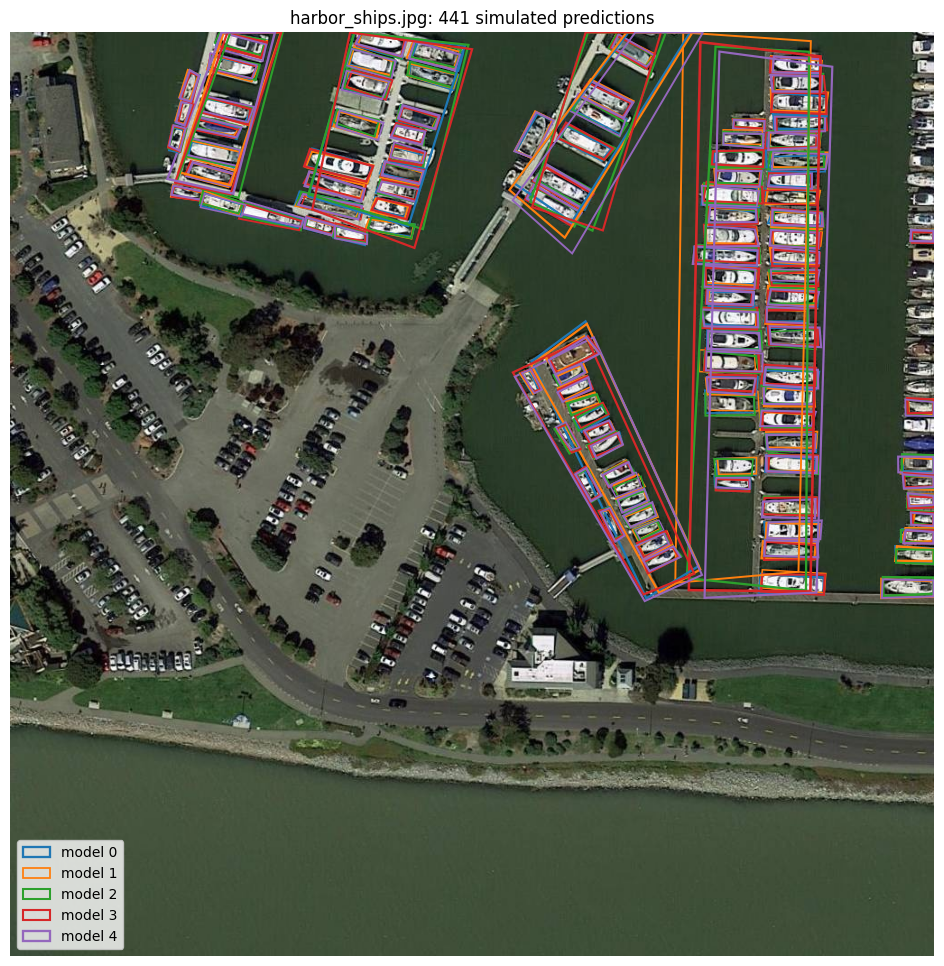

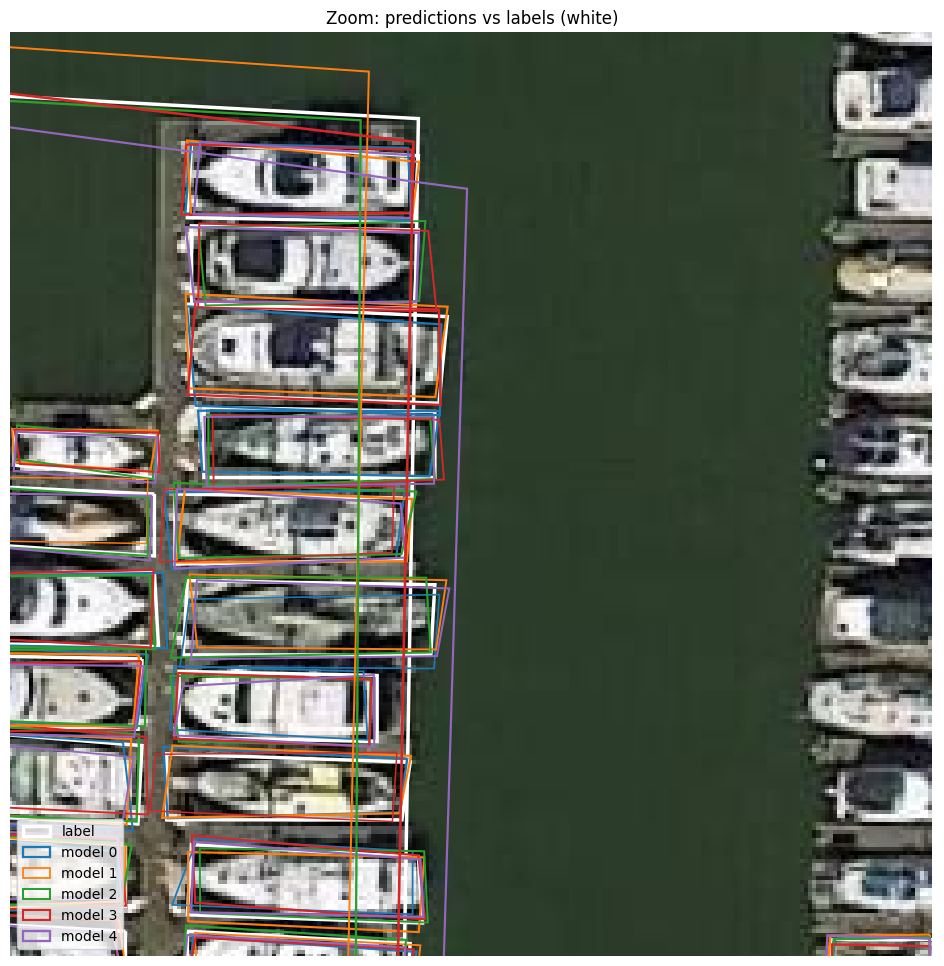

In [8]:
ax = new_figure(image, title='{}: {} simulated predictions'.format(IMAGE_NAME, len(predictions)))
draw_quadrangles(ax, predictions, color_by='model', legend='model', width_by_score=True)
plt.show()

ax = new_figure(image, title='Zoom: predictions vs labels (white)', crop=(800, 0, 1024, 224))
draw_quadrangles(ax, boxes, color='white', legend='label', linewidth=2.5)
draw_quadrangles(ax, predictions, color_by='model', legend='model', width_by_score=True)
plt.show()

## Harbor predictions

All simulated predictions for the `harbor` class, colored by model. Each harbor has 3 to 5 overlapping predictions.

Harbor objects: 5, predictions: 20


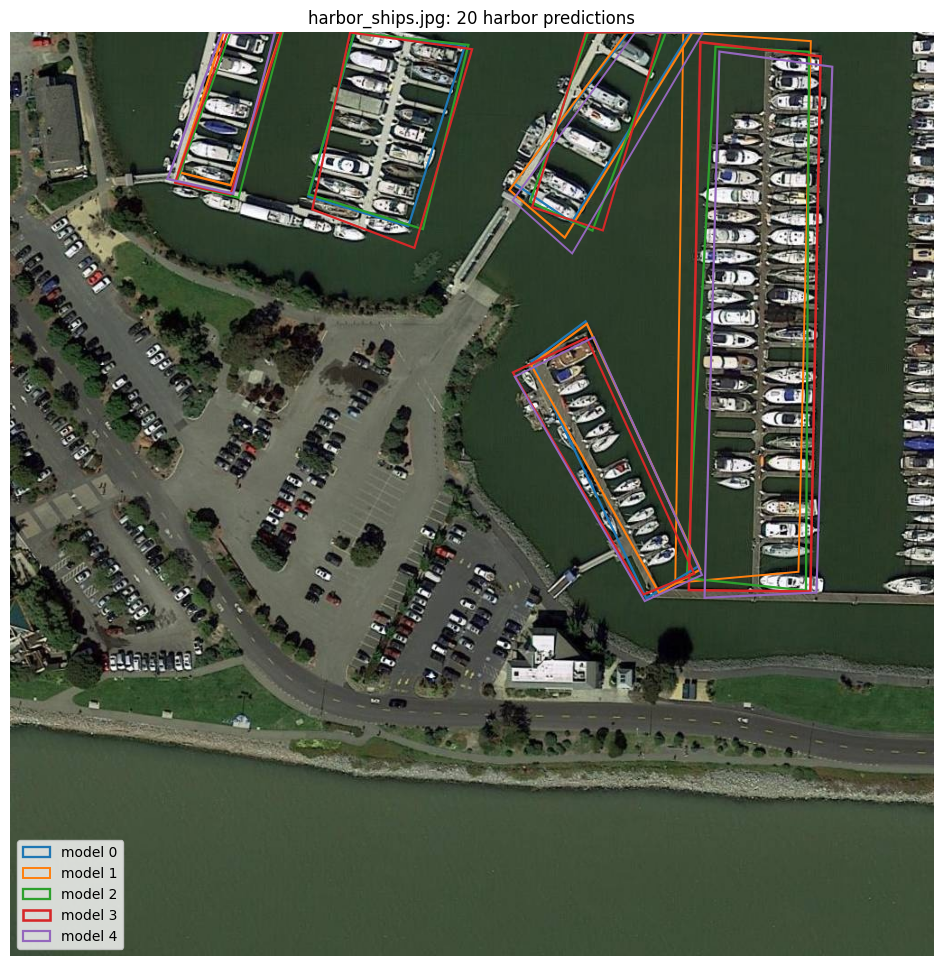

In [9]:
harbor_predictions = predictions[predictions['class_name'] == 'harbor'].reset_index(drop=True)
print('Harbor objects: {}, predictions: {}'.format(harbor_predictions['object_id'].nunique(), len(harbor_predictions)))

ax = new_figure(image, title='{}: {} harbor predictions'.format(IMAGE_NAME, len(harbor_predictions)))
draw_quadrangles(ax, harbor_predictions, color_by='model', legend='model', width_by_score=True)
plt.show()

## Weighted Boxes Fusion for quadrangles

`weighted_boxes_fusion_quadrangle` takes one list of boxes, scores and labels per model. Each box is 8 numbers `(x1, y1, x2, y2, x3, y3, x4, y4)` normalized to [0, 1], so we divide x by the image width and y by the image height, and convert the fused boxes back to pixels afterwards.

Boxes of the same class that overlap with IoU above `iou_thr` are fused into one box. Its corners are the average of the corners of the fused boxes, weighted by their scores.

In [10]:
def fuse_predictions(predictions, image_shape, iou_thr=IOU_THR, skip_box_thr=SKIP_BOX_THR, n_models=N_MODELS):
    """
    Run quadrangle WBF on a predictions DataFrame.
    :return: DataFrame with one row per fused box, corners in pixels
    """
    height, width = image_shape[:2]
    # (x, y) scale repeated for the 4 corners: pixels -> [0, 1]
    scale = np.array([width, height] * 4, dtype=float)

    # One list of boxes, scores and labels per model
    boxes_list, scores_list, labels_list = [], [], []
    for model in range(n_models):
        model_preds = predictions[predictions['model'] == model]
        boxes_list.append((model_preds[CORNER_COLS].to_numpy(dtype=float) / scale).tolist())
        scores_list.append(model_preds['score'].tolist())
        labels_list.append(model_preds['class_id'].tolist())

    fused_boxes, fused_scores, fused_labels = weighted_boxes_fusion_quadrangle(
        boxes_list, scores_list, labels_list, weights=None, iou_thr=iou_thr, skip_box_thr=skip_box_thr)

    fused = pd.DataFrame(np.asarray(fused_boxes) * scale, columns=CORNER_COLS).round(1)
    fused.insert(0, 'score', np.round(fused_scores, 3))
    fused.insert(0, 'class_id', np.asarray(fused_labels).astype(int))
    return fused


harbor_fused = fuse_predictions(harbor_predictions, image.shape)
print('{} harbor predictions were fused into {} boxes'.format(len(harbor_predictions), len(harbor_fused)))
harbor_fused

20 harbor predictions were fused into 5 boxes


,class_id,score,x1,y1,x2,y2,x3,y3,x4,y4
0,7,0.699,666.8,0.0,744.0,0.0,632.2,223.3,564.6,181.4
1,7,0.607,238.4,0.0,298.5,0.0,246.7,177.3,181.5,162.2
2,7,0.600,770.1,12.3,895.4,24.6,884.2,615.1,752.4,615.0
3,7,0.577,640.1,329.5,762.8,596.7,707.1,625.1,567.9,372.5
4,7,0.453,379.6,0.0,507.6,15.6,448.6,223.7,331.6,185.6


## Fused harbor boxes

The image again, now with the fused boxes. The number in each box is its fused confidence score.

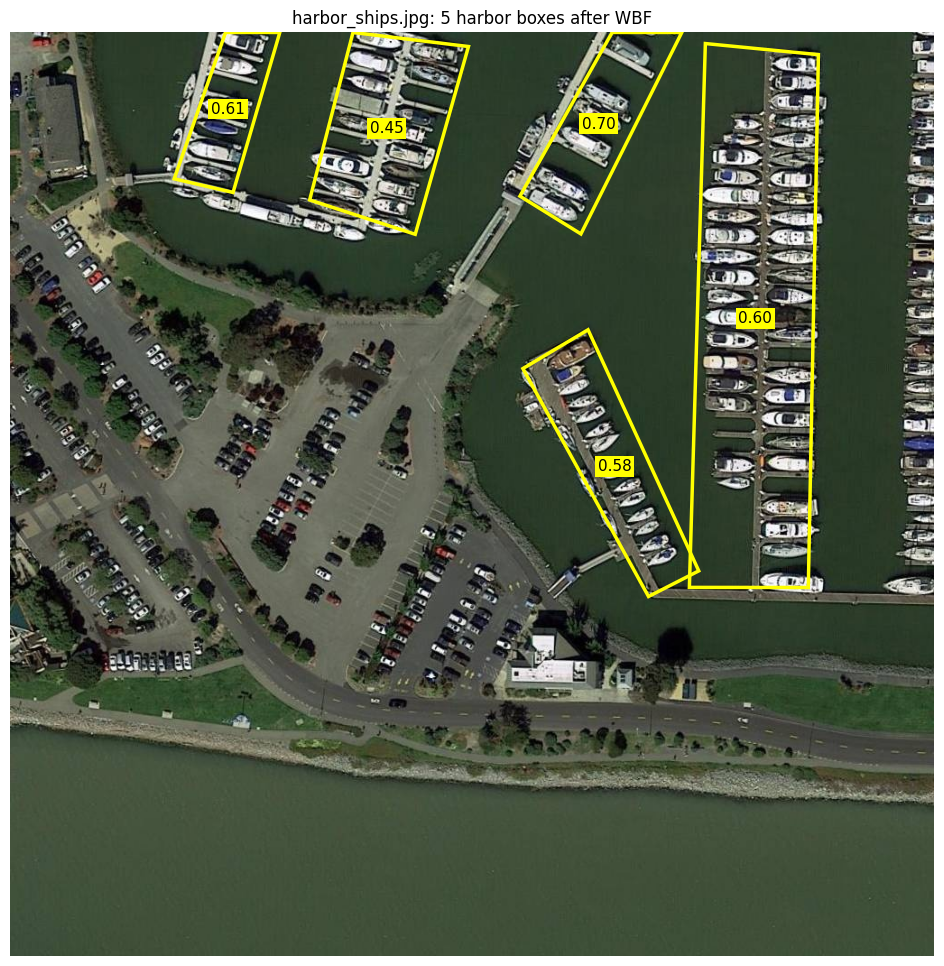

In [11]:
ax = new_figure(image, title='{}: {} harbor boxes after WBF'.format(IMAGE_NAME, len(harbor_fused)))
draw_quadrangles(ax, harbor_fused, color='yellow', linewidth=2.5, show_scores=True)
plt.show()

## Non-maximum suppression (NMS) for comparison

NMS is the usual alternative to WBF. For every group of overlapping boxes of one class it keeps the box with the highest score and throws the others away. WBF instead averages all boxes of the group.

The `nms` function of `ensemble_boxes` works only with axis-aligned boxes `(x1, y1, x2, y2)`, so for quadrangles we use a short NMS written here. It measures the overlap with `bb_intersection_over_union_quadrangle`, the same IoU that `weighted_boxes_fusion_quadrangle` uses.

In [12]:
def nms_predictions(predictions, iou_thr=NMS_IOU_THR):
    """
    Non-maximum suppression for quadrangles, done separately for each class.
    :param iou_thr: a box is dropped when its IoU with an already kept box is above this value
    :return: DataFrame with the kept predictions, unchanged, best score first
    """
    kept = []
    for class_id, group in predictions.groupby('class_id'):
        # Boxes of one class, best score first
        group = group.sort_values('score', ascending=False)
        coords = group[CORNER_COLS].to_numpy(dtype=float)
        remaining = list(range(len(group)))
        while remaining:
            # The best remaining box is kept ...
            best = remaining.pop(0)
            kept.append(group.index[best])
            # ... and every box that overlaps it too much is dropped
            remaining = [i for i in remaining if bb_intersection_over_union_quadrangle(coords[best], coords[i]) <= iou_thr]
    return predictions.loc[kept].sort_values('score', ascending=False).reset_index(drop=True)


harbor_nms = nms_predictions(harbor_predictions)
print('NMS kept {} of {} harbor predictions'.format(len(harbor_nms), len(harbor_predictions)))
harbor_nms[['model', 'class_name', 'score'] + CORNER_COLS]

NMS kept 5 of 20 harbor predictions


,model,class_name,score,x1,y1,x2,y2,x3,y3,x4,y4
0,3,harbor,0.910,764.6,10.7,897.8,26.6,886.5,619.5,751.8,618.0
1,1,harbor,0.822,236.3,0.0,299.9,0.0,244.0,169.3,186.2,154.8
2,0,harbor,0.772,684.8,0.0,753.2,0.0,622.1,210.2,558.3,167.2
3,0,harbor,0.766,381.3,0.0,503.7,14.6,441.0,214.8,330.1,181.7
4,0,harbor,0.765,577.5,364.5,637.3,320.2,762.9,591.2,704.7,627.1


## Boxes kept by NMS

The image with the boxes kept by NMS. Each of them is one of the original predictions, with its original score written in the box. These scores are higher than the WBF scores because WBF lowers the score of a box that was not found by all 5 models.

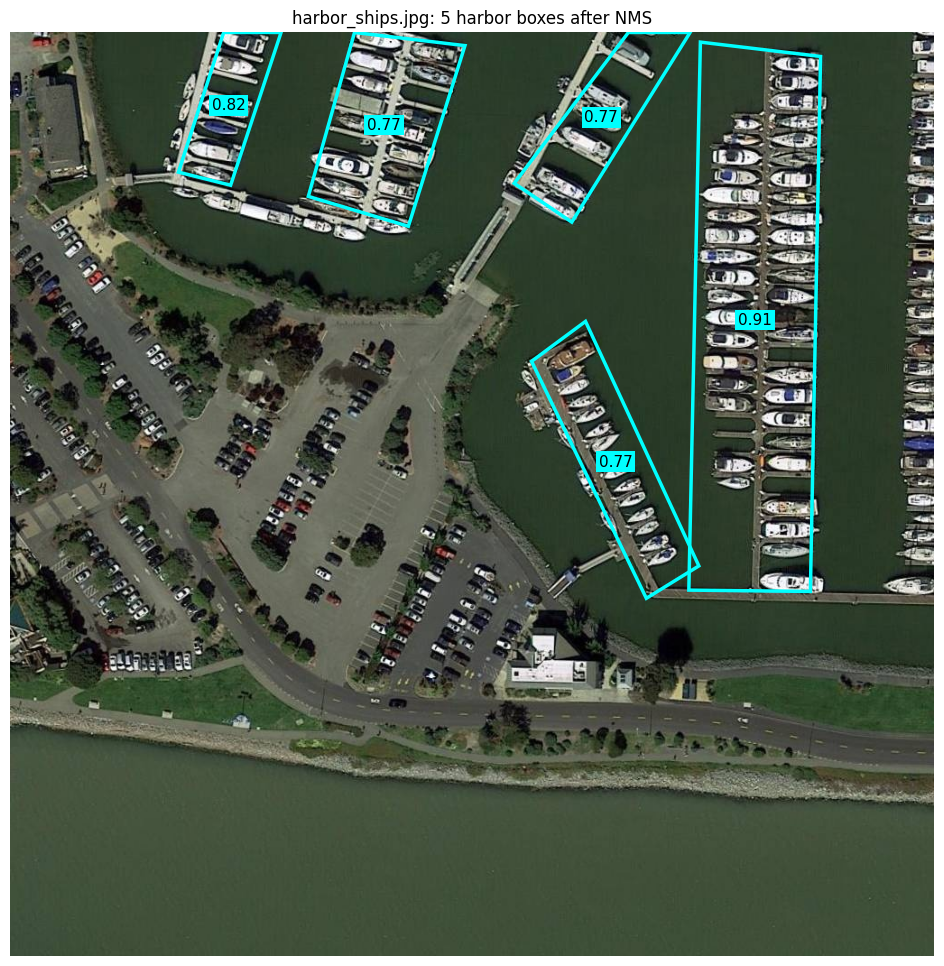

In [13]:
ax = new_figure(image, title='{}: {} harbor boxes after NMS'.format(IMAGE_NAME, len(harbor_nms)))
draw_quadrangles(ax, harbor_nms, color='cyan', linewidth=2.5, show_scores=True)
plt.show()

## Appendix: how the predictions file was generated

The function below was used once, as `generate_predictions(boxes, image.shape)`, to create `harbor_ships_predictions.csv`. Every prediction is the labelled quadrangle with:

- a small random shift of the whole box,
- a small random move of each of the 4 corners,
- a confidence score that is higher when the prediction is closer to the label (`label_error` is the mean distance between matching corners, as a fraction of the box size).

The amount of noise is proportional to the box size, so small ships and large harbors are disturbed to a similar degree.

After that, 2 predictions were added to the file by hand for the top-middle harbor (object 86, models 2 and 3), rotated the opposite way to the other 3 predictions of that harbor. Because of this the function is kept here for reference only and is not called.

In [14]:
def generate_predictions(boxes, image_shape, min_preds=3, max_preds=5, n_models=N_MODELS,
                         shift_std=0.04, corner_std=0.03, score_drop=5.0, score_noise=0.03,
                         score_range=(0.3, 0.99), seed=42):
    """
    Simulate model predictions from labelled quadrangles.
    :param boxes: labels of one image, with the 4 corners in pixels and w, h columns
    :param image_shape: (height, width, ...) of the image, predictions are clipped to it
    :param min_preds, max_preds: number of predictions generated per object
    :param n_models: number of simulated models, each predicts an object at most once
    :param shift_std: std of the shift of the whole box, as a fraction of the box size
    :param corner_std: std of the move of each corner, as a fraction of the box size
    :param score_drop: how fast the score falls as the prediction moves away from the label:
        score = 1 - score_drop * label_error
    :param score_noise: std of the random noise added to the score
    :param score_range: scores are clipped to this range
    :return: DataFrame with one row per prediction
    """
    rng = np.random.default_rng(seed)
    height, width = image_shape[:2]
    rows = []
    for object_id, row in boxes.iterrows():
        corners = row[CORNER_COLS].to_numpy(dtype=float).reshape(4, 2)
        # Box size in pixels: side of a square with the same area
        size = np.sqrt(row['w'] * row['h'])

        # Pick which models "detected" this object: 3 to 5 different models
        n_preds = rng.integers(min_preds, max_preds + 1)
        models = np.sort(rng.choice(n_models, size=n_preds, replace=False))

        for model in models:
            shift = rng.normal(0, shift_std * size, size=2)         # same for all 4 corners
            noise = rng.normal(0, corner_std * size, size=(4, 2))   # different for each corner
            pred = corners + shift + noise
            pred[:, 0] = np.clip(pred[:, 0], 0, width - 1)
            pred[:, 1] = np.clip(pred[:, 1], 0, height - 1)

            # How far the prediction is from the label: mean distance between matching
            # corners, as a fraction of the box size (0 = exactly on the label)
            # The label is clipped to the image in the same way as the prediction, so that
            # objects cut by the image border are not counted as far from their label.
            visible = np.column_stack([np.clip(corners[:, 0], 0, width - 1), np.clip(corners[:, 1], 0, height - 1)])
            label_error = np.linalg.norm(pred - visible, axis=1).mean() / size
            # The closer to the label, the higher the score, plus a little noise
            score = 1.0 - score_drop * label_error + rng.normal(0, score_noise)
            score = float(np.clip(score, *score_range))
            rows.append({
                'image': row['image'],
                'object_id': object_id,
                'model': int(model),
                'class_id': row['class_id'],
                'class_name': row['class_name'],
                'score': round(score, 3),
                'label_error': round(float(label_error), 4),
                **dict(zip(CORNER_COLS, pred.reshape(-1).round(1))),
            })
    return pd.DataFrame(rows)